In [17]:
#task 1

In [18]:
import pandas as pd
import matplotlib.pyplot as plt             #importing libraries and loading the csv
df_original = pd.DataFrame(pd.read_csv(r"C:\Users\rayan\OneDrive\Documents\GitHub\Student-capstone-project\data\raw.csv"))
df = df_original.copy()     #i made a copy so if anything goes wrong it doesnt get ruined

print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


-----------------------------------------------------------------
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  
---------------

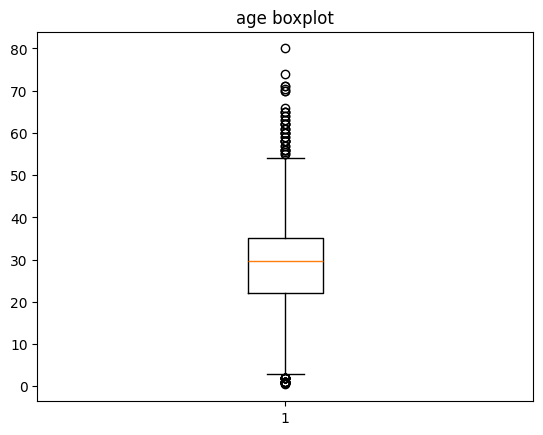

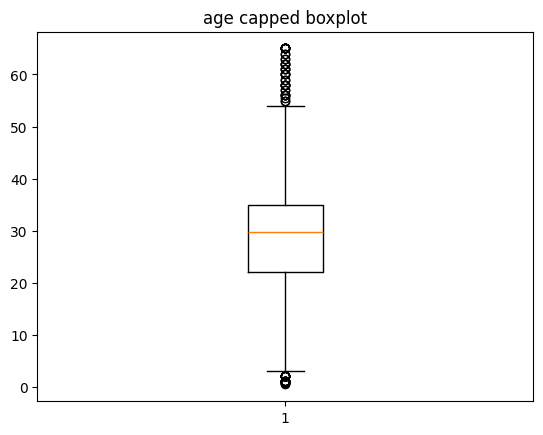

-----------------------------------------------------------------
info after modification
-----------------------------------------------------------------
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.640195    0.523008   
std     257.353842    0.486592    0.836071   12.820616    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   22.000000    0.000000   
50%     446.000000    0.000000    3.000000   29.699118    0.000000   
75%     668.500000    1.000000    3.000000   35.000000    1.000000   
max     891.000000    1.000000    3.000000   65.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   1

In [19]:
def clean_data(dataframe):
    #summerise the content of the dataframe
    print("-----------------------------------------------------------------")
    print(dataframe.describe())
    print("-----------------------------------------------------------------")
    print(dataframe.info())
    print("-----------------------------------------------------------------")
    rows = int((dataframe.shape)[0])
    columns = int((dataframe.shape)[1])
    print(f"rows: {rows}, columns: {columns}")   #to make it look more simple
    print("-----------------------------------------------------------------")
    print(dataframe.dtypes)
    print("-----------------------------------------------------------------")
    missing_list = dataframe.isnull().sum().sort_values(ascending = False).to_dict()                #find the missing values and decide what to do with them
    print("missing from each row:\n", missing_list)   #this shows the columns with missing values
    print("-----------------------------------------------------------------")
    dataframe.drop(columns=['Cabin'], inplace=True)    #i have decided to drop the (cabin) column because it has too many missing valuess to fill and is an expendable value in my oppinion
    dataframe['Age'] = dataframe['Age'].fillna(dataframe['Age'].mean())    #(age) is an important feature and doesnt have as many missing values as cabin so i decided to fill using mean since it is a numerical value
    dataframe['Embarked'] = dataframe['Embarked'].fillna(dataframe['Embarked'].mode()[0])     #since (embarked) is an object value and only missing 2 values i decided to use mode to fill
    dataframe["Embarked"] = dataframe["Embarked"].astype("category")

    print("duplicates in dataframe:", dataframe.duplicated().sum())
    #i will use the iqr method to find outliers
    
    plt.boxplot(dataframe['Age'])
    plt.title("age boxplot")        #show the bloxplot without finding outliers
    plt.show()

    q1 = dataframe["Age"].quantile(0.25)        #get the first and third quarter
    q3 = dataframe["Age"].quantile(0.75)           
    
    iqr = q3 -q1
    lower = q1 - 1.5*iqr                #IQR method
    upper = q3 + 1.5*iqr
    outliers = (dataframe["Age"] < lower) | (dataframe["Age"] > upper)
    up_cap = dataframe["Age"].quantile(0.99)
    dataframe["Age"] = dataframe["Age"].clip(upper = up_cap)
    
    plt.boxplot(dataframe['Age'])
    plt.title("age capped boxplot")         #to show the differance between before and after removing outliers
    plt.show()

    



    print("-----------------------------------------------------------------")
    print("info after modification")
    print("-----------------------------------------------------------------")
    print(dataframe.describe())
    print("-----------------------------------------------------------------")
    print(dataframe.info())
    print("-----------------------------------------------------------------")
    rows = int((dataframe.shape)[0])
    columns = int((dataframe.shape)[1])
    print(f"rows: {rows}, columns: {columns}")   
    print("-----------------------------------------------------------------")
    print("-----------------------------------------------------------------")
    missing_list = dataframe.isnull().sum().sort_values(ascending = False).to_dict()
    print("missing from each row:\n", missing_list)
    return dataframe

df = clean_data(df)


In [20]:
    #first check, no missing values in key columns
assert df['Age'].isnull().sum() == 0, "age still has missing values"
assert df['Embarked'].isnull().sum() == 0, "embarked still has missing values"

#second check, are target values valid
assert df['Survived'].isin([0, 1]).all(), "there are invalid values in survived"    

#third check, is the shape of the dataframe as expected
expected_columns = 11
assert df.shape[1] == expected_columns, "column amount is incorrect"



df.to_csv(r"C:\Users\rayan\OneDrive\Documents\GitHub\Student-capstone-project\data\cleaned\clean data.csv", index=False)        #make a new clean data file to use in other tasks